In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [47]:
# Data Transformation & Normalization
# - Normalizes pixel values for stable training

transform = transforms.Compose([
    transforms.ToTensor(),     # - Converts images to PyTorch tensors
   # Because neural networks work better with small numbers.
    transforms.Normalize((0.5,), (0.5,)) #   (mean=0.5, std=0.5 scales data roughly between -1 and 1)

])

In [48]:
# MNIST contains handwritten digit images (0–9)
# Each image size = 28x28 grayscale
train_dataset = datasets.MNIST(
    root="./data",
    train=True,           # Load training dataset
    download=True,
    transform=transform
)


In [49]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,          # Load testing dataset
    download=True,
    transform=transform
)

In [50]:
# batch_size=64 → Model processes 64 images at once
# shuffle=True → Prevents model from memorizing order

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


In [51]:
class DigitNN(nn.Module):
    def __init__(self):
        super().__init__()  #Call the parent class (nn.Module)

        self.network = nn.Sequential(

            # Convert 28x28 image into 784 vector
            nn.Flatten(),   #converts: 2D image → 1D vector of size 784

            # First Hidden Layer
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),  # Drop 30% neurons during training

            # Second Hidden Layer
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output Layer (10 classes: digits 0–9)
            nn.Linear(256, 10)
        )

    def forward(self, x):   #x is the input data to the model.
        return self.network(x)


In [ ]:
#Initialize Model
model = DigitNN()

# Used for multi-class classification
criterion = nn.CrossEntropyLoss()     # it tells how wrong our model is

# Adam(Adaptive Moment Estimation.) optimizer updates weights using adaptive learning rates
optimizer = optim.Adam(model.parameters(), lr=0.001)   #A smart weight updater - Automatically adjusts learning speed




In [53]:
#Training

epochs = 5

for epoch in range(epochs):

    model.train()   # Set model to training mode (activates Dropout)
    total_loss = 0.0 # We reset it loss for every epoch.

    for images, labels in train_loader:

        # Clear previous gradients to prevent accumulation
        optimizer.zero_grad() #Reset before new calculation

        # Forward pass: predict outputs
        outputs = model(images)

        # Compute loss between predictions and actual labels
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss for reporting
        # loss.item() - convert pytorch Tensor → normal number (float)
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Training Loss: {total_loss:.4f}")


Epoch 1/5 | Training Loss: 358.0782
Epoch 2/5 | Training Loss: 191.8196
Epoch 3/5 | Training Loss: 161.4003
Epoch 4/5 | Training Loss: 144.5546
Epoch 5/5 | Training Loss: 126.9145


In [54]:
#Testing

model.eval()   # We are in testing mode.

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        # Forward pass
        outputs = model(images)

        # Get predicted class (highest score)
        predictions = torch.argmax(outputs, dim=1)  #argmax- picks the index with highest value.

        # Count correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

# Calculate final accuracy
test_accuracy = correct / total


print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")


Final Test Accuracy: 0.9704


In [55]:
torch.save(model.state_dict(), "digit_model.pth")

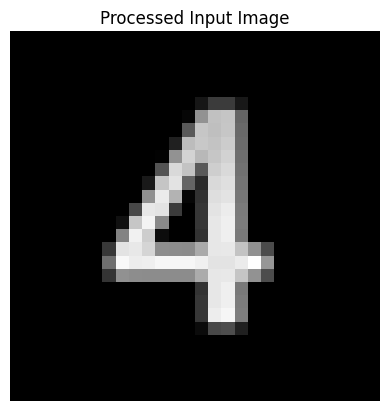

Predicted Digit: 4
Confidence: 0.9707512259483337


In [77]:
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

model.eval()

image_path = "/content/image1.png"  # Change this to your file name

# Load image
image = Image.open(image_path).convert("L")

# Resize to MNIST size
image = image.resize((28, 28))

# Invert image (IMPORTANT for MNIST)
image = ImageOps.invert(image)

# Show original processed image BEFORE transform
plt.imshow(image, cmap="gray")
plt.title("Processed Input Image")
plt.axis("off")
plt.show()

# Apply same transform used during training
image_tensor = transform(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# Predict
with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.softmax(output, dim=1)
    prediction = torch.argmax(probabilities, dim=1)
    confidence = torch.max(probabilities)

print("Predicted Digit:", prediction.item())
print("Confidence:", confidence.item())